In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
train = "train.csv"

df = pd.read_csv(train, sep =',')

#df.shape
#df.dtypes

nbLignes = len(df)
nbColonnes = len(df.columns)
df.head()


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


count the number of NA values for each variable

In [3]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [5]:
# Diviser la colonne PassengerId en deux parties et convertir en entiers
df[['PassengerId_1', 'PassengerId_2']] = df['PassengerId'].str.split('_', expand=True)
df['PassengerId_1'] = df['PassengerId_1']
df['PassengerId_2'] = df['PassengerId_2']
df['Null_Value'] = df['Age'].isnull()



# Afficher le DataFrame avec la colonne 'Key'
print(df.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported PassengerId_1 PassengerId_2  Null_Value  
0        False          0001            01     

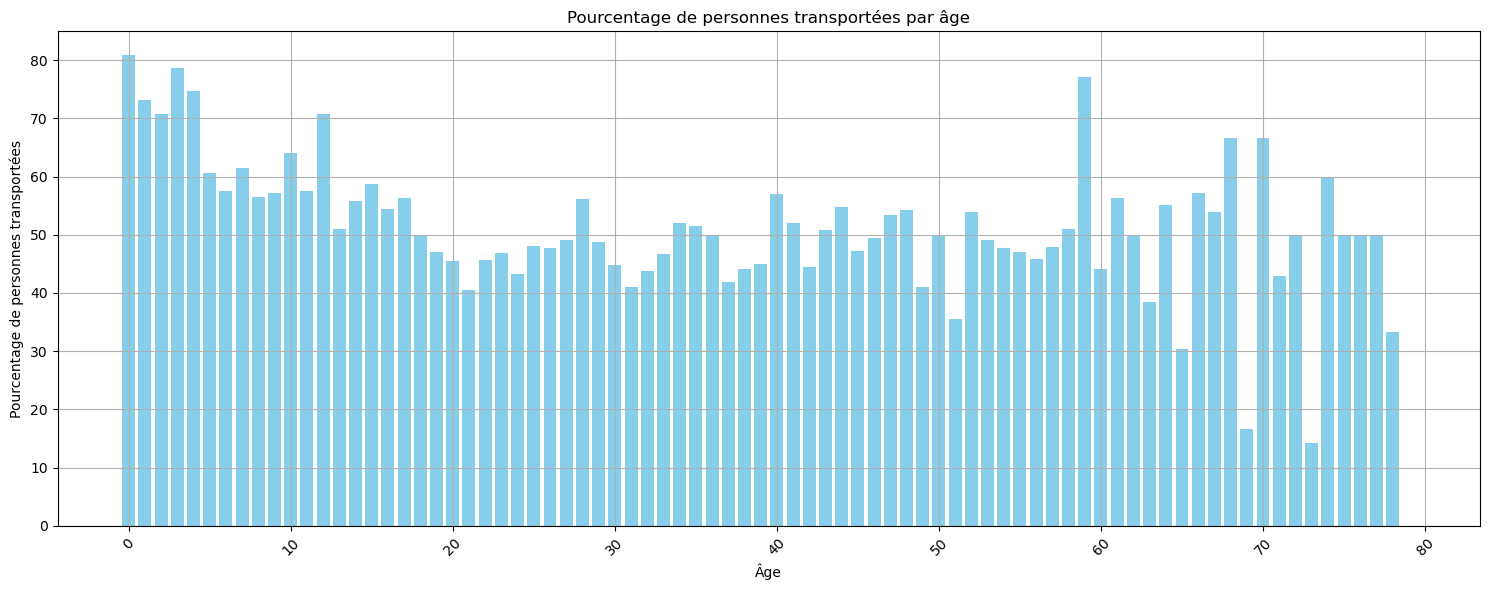

In [6]:
import matplotlib.pyplot as plt

# Calculer le nombre total de personnes pour chaque âge
age_counts = df.groupby('Age')['Transported'].count()

# Calculer le nombre de personnes transportées pour chaque âge
transported_counts = df.groupby('Age')['Transported'].sum()

# Calculer le pourcentage de personnes transportées pour chaque âge
transported_percentages = (transported_counts / age_counts) * 100

# Créer le diagramme à barres
plt.figure(figsize=(15, 6))
plt.bar(transported_percentages.index, transported_percentages.values, color='skyblue')
plt.xlabel('Âge')
plt.ylabel('Pourcentage de personnes transportées')
plt.title('Pourcentage de personnes transportées par âge')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Afficher les différentes valeurs de la colonne 'Cabin'
print(df['Cabin'].unique())


['B/0/P' 'F/0/S' 'A/0/S' ... 'G/1499/S' 'G/1500/S' 'E/608/S']
